# PhiSat-2 & Sentinel-2 Dataset Visualization
Visualize triplets of multi-modal satellite imagery: PhiSat-2 real, PhiSat-2 simulated, and Sentinel-2B.

## 1. Import Required Libraries

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load HDF5 Dataset

In [2]:
h5_path = Path("/shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5")

# Open HDF5 file in read mode
f = h5py.File(h5_path, 'r')
print(f"HDF5 file opened: {h5_path}")
print(f"File exists: {h5_path.exists()}")

# Print file structure
print("\nDataset structure:")
def print_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"  {name}: {obj.shape} {obj.dtype}")
    elif isinstance(obj, h5py.Group):
        print(f"  {name}/ (group)")

f.visititems(print_structure)

HDF5 file opened: /shared/projects/phisat2/data/processed/triplets_v1/phisat2_s2b_dataset_v1.h5
File exists: True

Dataset structure:
  metadata/ (group)
  metadata/center_lat: (259150,) float32
  metadata/center_lon: (259150,) float32
  metadata/date_phi: (259150,) object
  metadata/date_s2b: (259150,) object
  metadata/koppen_zone: (259150,) int8
  metadata/ll_lat: (259150,) float32
  metadata/ll_lon: (259150,) float32
  metadata/lr_lat: (259150,) float32
  metadata/lr_lon: (259150,) float32
  metadata/product_id: (259150,) int32
  metadata/ul_lat: (259150,) float32
  metadata/ul_lon: (259150,) float32
  metadata/ur_lat: (259150,) float32
  metadata/ur_lon: (259150,) float32
  real/ (group)
  real/images: (259150, 8, 256, 256) int16
  real/masks: (259150, 256, 256) uint8
  s2b/ (group)
  s2b/images: (259150, 7, 256, 256) int16
  s2b/masks: (259150, 256, 256) uint8
  sim/ (group)
  sim/images: (259150, 8, 256, 256) int16


## 3. Explore Dataset and Get Sample Metadata

In [3]:
# Get dataset sizes
n_samples = f['real/images'].shape[0]
print(f"Total samples in dataset: {n_samples}")

# Get sample indices to visualize
sample_indices = np.random.choice(n_samples, size=min(3, n_samples), replace=False)
print(f"\nVisualizing samples at indices: {sample_indices}")

# Get metadata for first sample
if 'metadata' in f:
    print("\nAvailable metadata keys:")
    for key in f['metadata'].keys():
        print(f"  - {key}: {f['metadata'][key].shape}")
    
    # Print metadata for first sample
    idx = sample_indices[0]
    print(f"\nMetadata for sample {idx}:")
    for key in f['metadata'].keys():
        val = f['metadata'][key][idx]
        if isinstance(val, bytes):
            val = val.decode('utf-8')
        print(f"  {key}: {val}")

Total samples in dataset: 259150

Visualizing samples at indices: [154726 100713  35292]

Available metadata keys:
  - center_lat: (259150,)
  - center_lon: (259150,)
  - date_phi: (259150,)
  - date_s2b: (259150,)
  - koppen_zone: (259150,)
  - ll_lat: (259150,)
  - ll_lon: (259150,)
  - lr_lat: (259150,)
  - lr_lon: (259150,)
  - product_id: (259150,)
  - ul_lat: (259150,)
  - ul_lon: (259150,)
  - ur_lat: (259150,)
  - ur_lon: (259150,)

Metadata for sample 154726:
  center_lat: 38.695804595947266
  center_lon: -9.282366752624512
  date_phi: 2025-07-30 11:42:27
  date_s2b: 2025-08-01
  koppen_zone: 0
  ll_lat: 38.69169616699219
  ll_lon: -9.290684700012207
  lr_lat: 38.68923568725586
  lr_lon: -9.277066230773926
  product_id: 2930
  ul_lat: 38.702369689941406
  ul_lon: -9.28766918182373
  ur_lat: 38.699913024902344
  ur_lon: -9.274046897888184


## 4. Visualize Triplets (Real, Simulated, Sentinel-2)

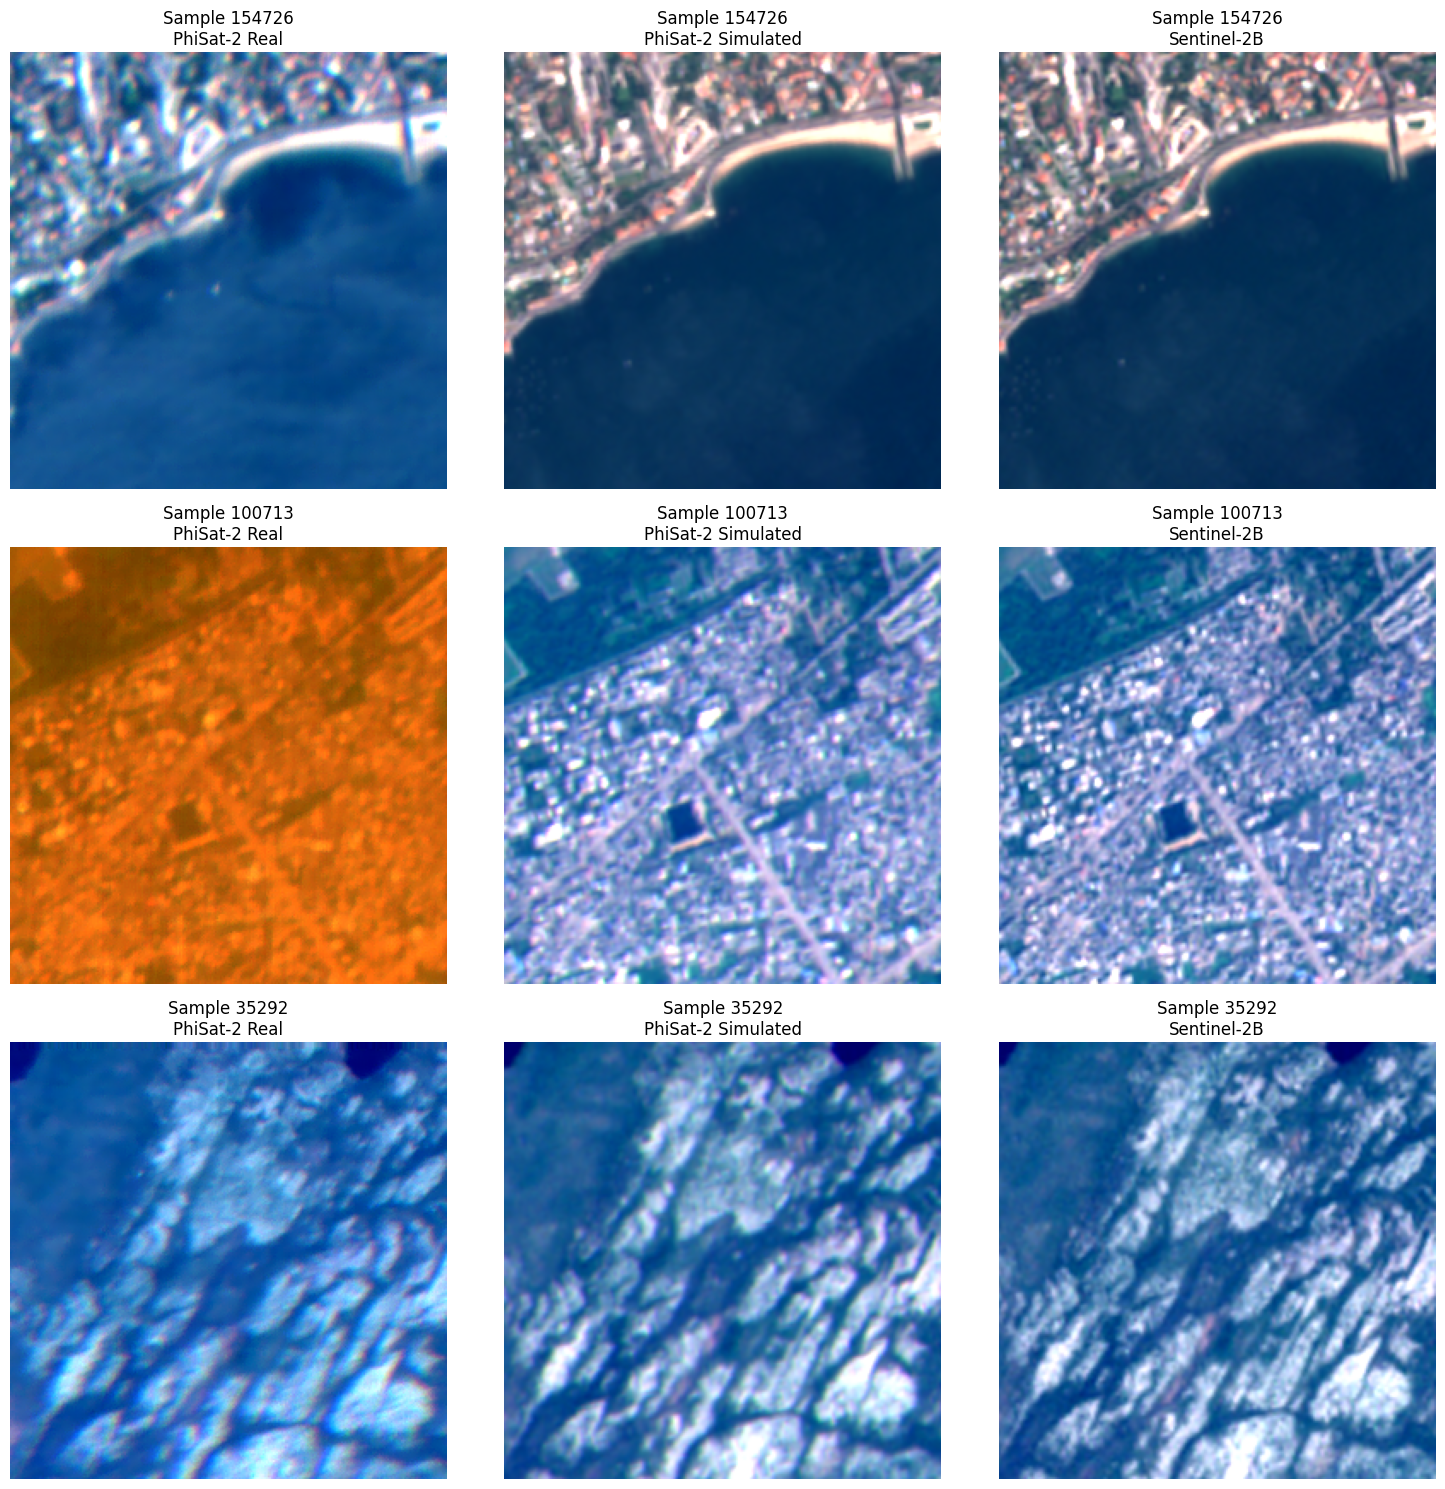


✓ Visualized 3 triplets


In [4]:
def normalize_image(img, percentile=2):
    """Normalize image to 0-1 range using percentile clipping."""
    p_low = np.percentile(img, percentile)
    p_high = np.percentile(img, 100 - percentile)
    img_norm = (img - p_low) / (p_high - p_low + 1e-6)
    return np.clip(img_norm, 0, 1)

# Visualize triplets for selected samples
n_show = len(sample_indices)
fig, axes = plt.subplots(n_show, 3, figsize=(15, 5 * n_show))

if n_show == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(sample_indices):
    # Load data
    real = f['real/images'][idx]  # (8, 256, 256)
    sim = f['sim/images'][idx]    # (8, 256, 256)
    s2b = f['s2b/images'][idx]    # (7, 256, 256)
    
    # Create RGB composites
    # PhiSat-2 (real/sim): Band 3 (Red), Band 2 (Green), Band 1 (Blue)
    real_rgb = np.stack([real[3], real[2], real[1]], axis=0)
    sim_rgb = np.stack([sim[3], sim[2], sim[1]], axis=0)
    
    # Sentinel-2: Band 2 (Red=B04), Band 1 (Green=B03), Band 0 (Blue=B02)
    s2b_rgb = np.stack([s2b[2], s2b[1], s2b[0]], axis=0)
    
    # Normalize and transpose to (H, W, 3)
    real_rgb = np.transpose(normalize_image(real_rgb), (1, 2, 0))
    sim_rgb = np.transpose(normalize_image(sim_rgb), (1, 2, 0))
    s2b_rgb = np.transpose(normalize_image(s2b_rgb), (1, 2, 0))
    
    # Display
    axes[row, 0].imshow(real_rgb)
    axes[row, 0].set_title(f"Sample {idx}\nPhiSat-2 Real")
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(sim_rgb)
    axes[row, 1].set_title(f"Sample {idx}\nPhiSat-2 Simulated")
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(s2b_rgb)
    axes[row, 2].set_title(f"Sample {idx}\nSentinel-2B")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Visualized {n_show} triplets")

## 5. (Optional) Visualize Cloud and SCL Masks

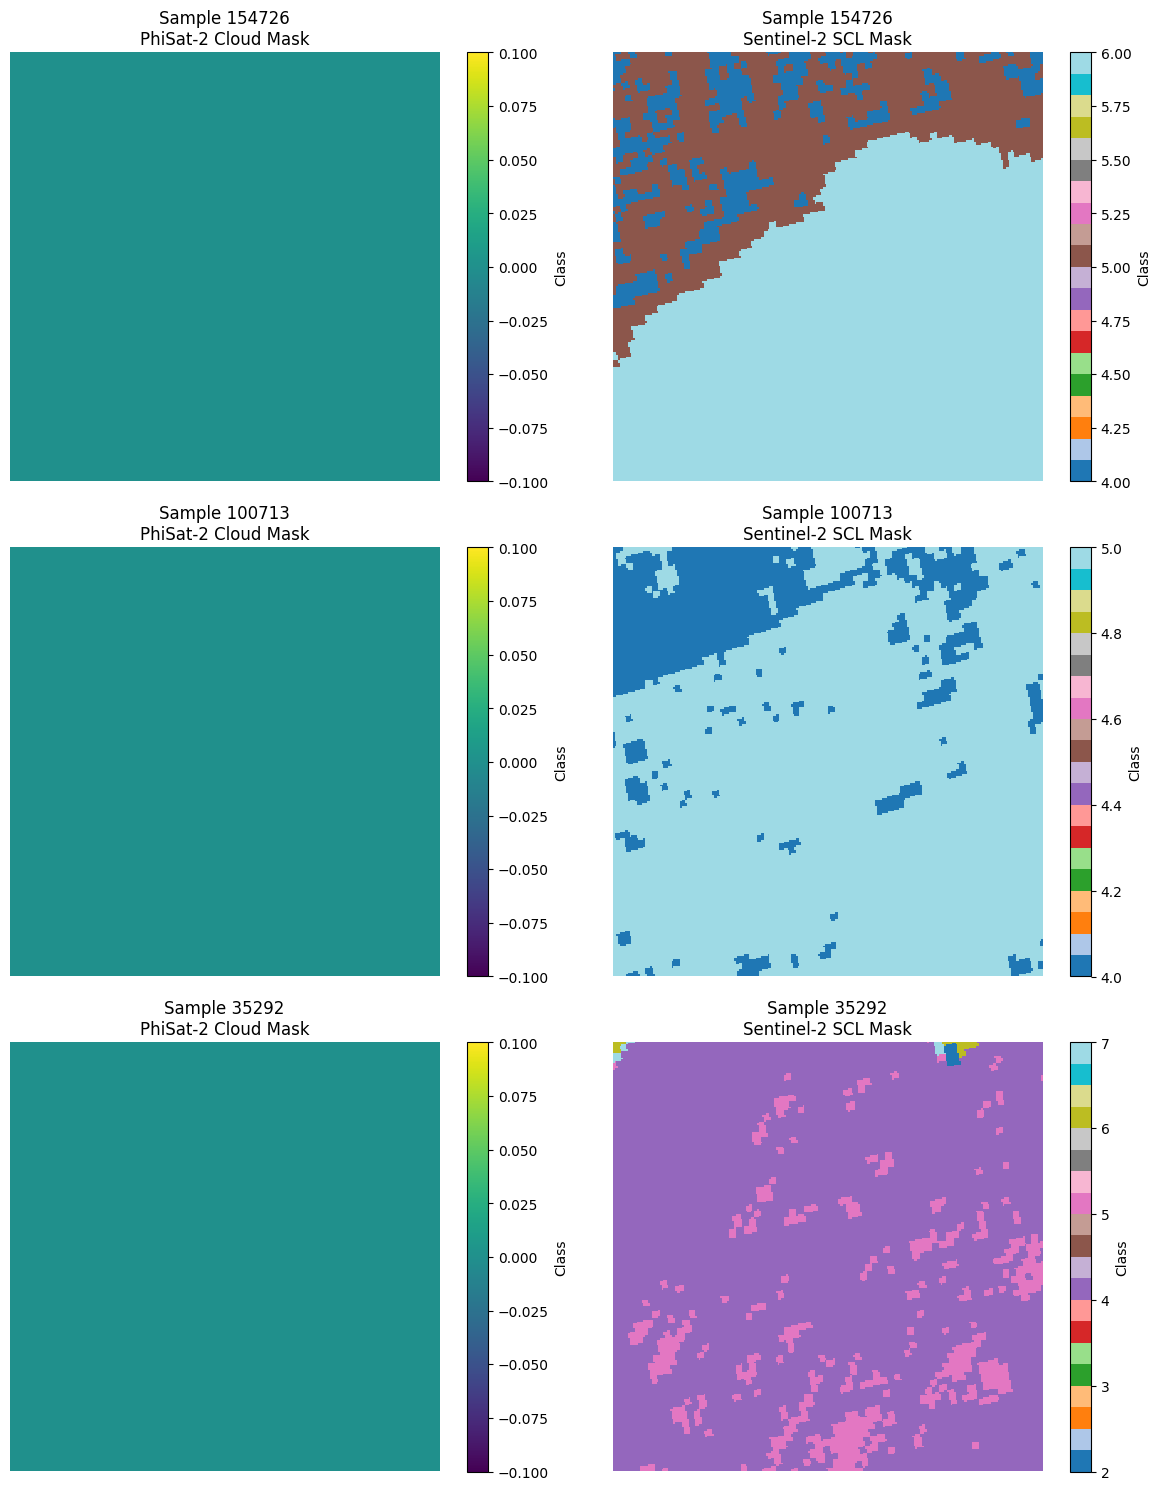

✓ Cloud masks (0=clear, 1=thick, 2=thin, 3=shadow)
✓ SCL masks: 0=No data, 1=Saturated, 2=Dark, 3=Shadow, 4=Vegetation, 5=Soil, 6=Water, 7=Unclassified, 8=Clouds medium, 9=Clouds high, 10=Cirrus, 11=Snow


In [5]:
# Visualize masks
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(12, 5 * len(sample_indices)))

if len(sample_indices) == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(sample_indices):
    # Load masks
    real_mask = f['real/masks'][idx]  # Cloud mask: 0=clear, 1=thick, 2=thin, 3=shadow
    s2b_mask = f['s2b/masks'][idx]    # SCL mask: 0-11 different classes
    
    # Display
    im0 = axes[row, 0].imshow(real_mask, cmap='viridis', interpolation='nearest')
    axes[row, 0].set_title(f"Sample {idx}\nPhiSat-2 Cloud Mask")
    axes[row, 0].axis('off')
    plt.colorbar(im0, ax=axes[row, 0], label='Class')
    
    im1 = axes[row, 1].imshow(s2b_mask, cmap='tab20', interpolation='nearest')
    axes[row, 1].set_title(f"Sample {idx}\nSentinel-2 SCL Mask")
    axes[row, 1].axis('off')
    plt.colorbar(im1, ax=axes[row, 1], label='Class')

plt.tight_layout()
plt.show()

print("✓ Cloud masks (0=clear, 1=thick, 2=thin, 3=shadow)")
print("✓ SCL masks: 0=No data, 1=Saturated, 2=Dark, 3=Shadow, 4=Vegetation, 5=Soil, 6=Water, 7=Unclassified, 8=Clouds medium, 9=Clouds high, 10=Cirrus, 11=Snow")

## 6. Cleanup

In [6]:
# Close HDF5 file
f.close()
print("HDF5 file closed")

HDF5 file closed
